# Autoencoder para `image_type == "V"`

Notebook focado em aprender a estrutura visual do subconjunto raro `V` e gerar amostras sintéticas para experimentar aumento de dados.

- o notebook usa apenas imagens `V` para treinar o autoencoder;
- a geração usa o espaço latente do autoencoder, então as imagens sintéticas são candidatas a augmentação, não substitutos diretos do dado real.

In [8]:
import gc
import os
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image, ImageOps
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

In [9]:
SEED = 42

DATA_ROOT = Path('')
DATASET_DIR = DATA_ROOT / 'MIQR-CC-Dataset'
METADATA_PATH = DATASET_DIR / 'metadata.csv'
PROCESSED_DIR = DATASET_DIR / 'processed'
RAW_DIR = DATASET_DIR / 'raw'

RESULTS_DIR = Path('results/auto_encode_V')
MODELS_DIR = Path('models/auto_encode_V')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Hardware ──────────────────────────────────────────────────────────────────
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = torch.cuda.is_available()

# ── Image ─────────────────────────────────────────────────────────────────────
IMAGE_SIZE = (224, 224)
GEOMETRY_MODE = 'pad_resize_if_rect'
USE_CLAHE = True

# ── DataLoader ────────────────────────────────────────────────────────────────
BATCH_SIZE = 16
NUM_WORKERS = 0

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS = 60
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 10
NOISE_STD = 0.05  # std of Gaussian noise added to inputs (denoising AE); set 0 to disable


In [10]:
import torch.nn as nn


class ConvBlock(nn.Module):
    """Conv -> BN -> LeakyReLU (encoder building block)."""
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    """ConvTranspose -> BN -> ReLU (decoder building block)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConvAutoencoder(nn.Module):
    """
    Convolutional autoencoder for grayscale images (1-channel input/output).
    Input:  (B, 3, H, W)  — RGB; first thing in forward is a 3->1 projection.
    Output: (B, 3, H, W)  — reconstructed RGB.
    Latent: bottleneck at IMAGE_SIZE // 32.
    """
    def __init__(self, latent_dim=256):
        super().__init__()
        # Encoder: 3 -> 32 -> 64 -> 128 -> 256 -> 512
        self.encoder = nn.Sequential(
            ConvBlock(3,   32,  stride=2),   # H/2
            ConvBlock(32,  64,  stride=2),   # H/4
            ConvBlock(64,  128, stride=2),   # H/8
            ConvBlock(128, 256, stride=2),   # H/16
            ConvBlock(256, 512, stride=2),   # H/32
        )
        # Bottleneck (1x1 conv to compress channel dim to latent_dim and back)
        self.bottleneck_enc = nn.Conv2d(512, latent_dim, kernel_size=1, bias=False)
        self.bottleneck_dec = nn.Conv2d(latent_dim, 512, kernel_size=1, bias=False)
        # Decoder: 512 -> 256 -> 128 -> 64 -> 32 -> 3
        self.decoder = nn.Sequential(
            UpBlock(512, 256),   # H/16
            UpBlock(256, 128),   # H/8
            UpBlock(128, 64),    # H/4
            UpBlock(64,  32),    # H/2
            UpBlock(32,  3),     # H
            nn.Sigmoid(),        # pixel values in [0, 1]
        )

    def encode(self, x):
        return self.bottleneck_enc(self.encoder(x))

    def decode(self, z):
        return self.decoder(self.bottleneck_dec(z))

    def forward(self, x):
        return self.decode(self.encode(x))


# ── Instantiate and move to device ────────────────────────────────────────────
LATENT_DIM = 256  # bottleneck channels; reduce for a tighter representation

model = ConvAutoencoder(latent_dim=LATENT_DIM).to(DEVICE)
criterion = nn.L1Loss()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: ConvAutoencoder | latent_dim={LATENT_DIM} | params={total_params:,} | device={DEVICE}')


Model: ConvAutoencoder | latent_dim=256 | params=4,619,494 | device=cuda


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 001 | train 0.43645 | val 0.39575


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

Epoch 018 | train 0.38913 | val 0.39395


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch 019 | train 0.38709 | val 0.39395
Early stopping acionado.


,epoch,train_loss,val_loss
14,15,0.391175,0.393947
15,16,0.392105,0.393947
16,17,0.385927,0.393947
17,18,0.389126,0.393947
18,19,0.387090,0.393947


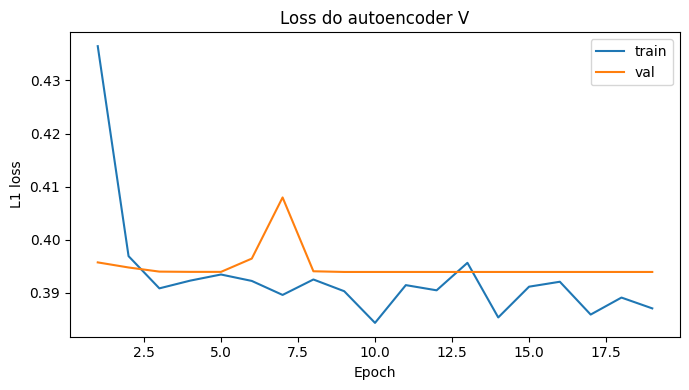

In [11]:
import os
import sys
import importlib

os.environ.setdefault('TORCHDYNAMO_DISABLE', '1')


def reset_dynamo_modules():
    dynamo_keys = [k for k in list(sys.modules.keys()) if k == 'torch._dynamo' or k.startswith('torch._dynamo.')]
    for key in dynamo_keys:
        del sys.modules[key]


def try_recover_dynamo():
    try:
        reset_dynamo_modules()
        dyn = importlib.import_module('torch._dynamo')
        dyn.config.suppress_errors = True
        return True
    except Exception as exc:
        print(f'Info: torch._dynamo ainda indisponível ({exc}).')
        return False


_ = try_recover_dynamo()

def pad_to_square(image: Image.Image, fill=(0, 0, 0)) -> Image.Image:
    w, h = image.size
    if w == h:
        return image
    side = max(w, h)
    canvas = Image.new(image.mode, (side, side), fill)
    canvas.paste(image, ((side - w) // 2, (side - h) // 2))
    return canvas


def apply_clahe_rgb(image: Image.Image, clip_limit=2.0, tile_grid_size=(8, 8)) -> Image.Image:
    rgb = np.array(image.convert('RGB'))
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_channel = clahe.apply(l_channel)
    merged = cv2.merge((l_channel, a_channel, b_channel))
    out = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return Image.fromarray(out)


def preprocess_image(image: Image.Image, geometry_mode='pad_resize_if_rect', use_clahe=True) -> Image.Image:
    image = image.convert('RGB')
    if use_clahe:
        image = apply_clahe_rgb(image)
    if geometry_mode == 'pad_resize_if_rect':
        image = pad_to_square(image)
    elif geometry_mode == 'direct_resize':
        pass
    else:
        raise ValueError(f'Unknown geometry_mode: {geometry_mode}')
    return image.resize((IMAGE_SIZE[0], IMAGE_SIZE[1]), Image.Resampling.BICUBIC)


def build_optimizer(model):
    # Try AdamW first.
    try:
        return torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    except Exception as exc:
        print(f'AdamW falhou ({exc}). Tentando reset de Dynamo e retry.')

    # Retry after a full dynamo reset.
    _ = try_recover_dynamo()
    try:
        return torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    except Exception as exc:
        print(f'Segundo AdamW falhou ({exc}). Tentando Adam.')

    # Last fallback to Adam.
    _ = try_recover_dynamo()
    try:
        return torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    except Exception as exc:
        raise RuntimeError(
            'Falha ao criar optimizer por estado inconsistente do torch._dynamo. '
            'Reinicie o kernel e execute de novo desde a célula 2.'
        ) from exc


if 'FINAL_CLASSES' not in globals():
    FINAL_CLASSES = ['Biliary Leaks', 'Lithiasis', 'Normal', 'Stricture']
if 'FUSED_LABEL_MAP' not in globals():
    FUSED_LABEL_MAP = {
        'Benign Stricture': 'Stricture',
        'Malignant Stricture': 'Stricture',
        'Biliary Leaks': 'Biliary Leaks',
        'Lithiasis': 'Lithiasis',
        'Normal': 'Normal',
    }
if 'EXCLUDED_LABELS' not in globals():
    EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled'}
if 'class_to_idx' not in globals():
    class_to_idx = {name: idx for idx, name in enumerate(FINAL_CLASSES)}
if 'GEOMETRY_MODE' not in globals():
    GEOMETRY_MODE = 'pad_resize_if_rect'
if 'USE_CLAHE' not in globals():
    USE_CLAHE = True

if 'v_real' not in globals() or 'final_label' not in getattr(v_real, 'columns', []):
    meta_local = pd.read_csv(METADATA_PATH)
    meta_local['Keep'] = meta_local['Keep'].astype(str).str.strip().str.lower()
    meta_local['Label'] = meta_local['Label'].astype(str).str.strip()
    meta_local['image_type'] = meta_local['image_type'].astype(str).str.strip()
    meta_local = meta_local[(meta_local['Keep'] == 'keep') & (meta_local['image_type'] == 'V') & (~meta_local['Label'].str.lower().isin(EXCLUDED_LABELS))].copy()
    meta_local['final_label'] = meta_local['Label'].map(FUSED_LABEL_MAP)
    meta_local = meta_local[meta_local['final_label'].isin(FINAL_CLASSES)].copy()
    meta_local['group_key'] = (
        meta_local['patient_id'].astype(str).str.strip() + '_' +
        meta_local['exam_date'].astype(str).str.strip() + '_' +
        meta_local['exam_time'].astype(str).str.strip()
    )

    def _resolve_image_path_local(row):
        candidates = []
        for column in ['processed_image_path', 'raw_image_path']:
            value = row.get(column, None)
            if pd.isna(value):
                continue
            path_value = Path(str(value))
            if path_value.is_absolute():
                candidates.append(path_value)
            else:
                candidates.append(DATASET_DIR / path_value)
                candidates.append(DATASET_DIR / path_value.name)
                candidates.append(PROCESSED_DIR / path_value.name)
                candidates.append(RAW_DIR / path_value.name)
        for candidate in candidates:
            if candidate.exists():
                return candidate
        return None

    meta_local['image_path'] = meta_local.apply(_resolve_image_path_local, axis=1)
    meta_local = meta_local[meta_local['image_path'].notna()].copy()
    meta_local['target'] = meta_local['final_label'].map(class_to_idx).astype(int)
    v_real = meta_local.copy()

if 'train_v_real' not in globals() or 'val_v' not in globals() or 'test_v' not in globals():
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
    train_val_idx, test_idx = next(gss_test.split(v_real, groups=v_real['group_key']))
    train_val_df = v_real.iloc[train_val_idx].copy().reset_index(drop=True)
    test_v_source = v_real.iloc[test_idx].copy().reset_index(drop=True)

    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
    train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['group_key']))
    train_v_source = train_val_df.iloc[train_idx].copy().reset_index(drop=True)
    val_v_source = train_val_df.iloc[val_idx].copy().reset_index(drop=True)

    train_v_real = train_v_source[['image_path', 'patient_id', 'final_label', 'target', 'group_key']].copy()
    val_v = val_v_source[['image_path', 'patient_id', 'final_label', 'target', 'group_key']].copy()
    test_v = test_v_source[['image_path', 'patient_id', 'final_label', 'target', 'group_key']].copy()


class VOnlyDataset(Dataset):
    def __init__(self, frame, geometry_mode='pad_resize_if_rect', use_clahe=True, noise_std=0.0):
        self.frame = frame.reset_index(drop=True).copy()
        self.geometry_mode = geometry_mode
        self.use_clahe = use_clahe
        self.noise_std = noise_std

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        image = preprocess_image(image, geometry_mode=self.geometry_mode, use_clahe=self.use_clahe)
        clean = transforms.ToTensor()(image)
        if self.noise_std > 0:
            noisy = (clean + self.noise_std * torch.randn_like(clean)).clamp(0.0, 1.0)
        else:
            noisy = clean
        return noisy, clean, row['group_key'], str(row['image_path'])


train_ds = VOnlyDataset(train_v_real, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE, noise_std=NOISE_STD)
val_ds = VOnlyDataset(val_v, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE, noise_std=0.0)
test_ds = VOnlyDataset(test_v, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE, noise_std=0.0)

class_counts = train_v_real['target'].value_counts().sort_index()
class_weights = torch.tensor(len(train_v_real) / (len(class_counts) * class_counts.values), dtype=torch.float32, device=DEVICE)
weight_lookup = {i: float(w) for i, w in enumerate(class_weights.detach().cpu().numpy())}
sample_weights = train_v_real['target'].map(weight_lookup).astype(float).tolist()
train_sampler = torch.utils.data.WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

optimizer = build_optimizer(model)
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
best_val_loss = float('inf')
best_path = MODELS_DIR / 'best_autoencoder_v.pt'
history = []
patience_counter = 0


def run_epoch(loader, train_mode=True):
    model.train(train_mode)
    total_loss = 0.0
    total_items = 0
    for noisy, clean, _, _ in tqdm(loader, leave=False):
        noisy = noisy.to(DEVICE, non_blocking=True)
        clean = clean.to(DEVICE, non_blocking=True)
        batch_size = noisy.size(0)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=torch.cuda.is_available()):
                recon = model(noisy)
                loss = criterion(recon, clean)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                recon = model(noisy)
                loss = criterion(recon, clean)

        total_loss += float(loss.item()) * batch_size
        total_items += batch_size
    return total_loss / max(total_items, 1)


for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train_mode=True)
    val_loss = run_epoch(val_loader, train_mode=False)
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
    print(f'Epoch {epoch:03d} | train {train_loss:.5f} | val {val_loss:.5f}')

    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'best_val_loss': best_val_loss,
            'image_size': IMAGE_SIZE,
            'noise_std': NOISE_STD,
            'seed': SEED,
        }, best_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print('Early stopping acionado.')
            break

history_df = pd.DataFrame(history)
history_path = RESULTS_DIR / 'training_history.csv'
history_df.to_csv(history_path, index=False)
display(history_df.tail())

plt.figure(figsize=(7, 4))
plt.plot(history_df['epoch'], history_df['train_loss'], label='train')
plt.plot(history_df['epoch'], history_df['val_loss'], label='val')
plt.title('Loss do autoencoder V')
plt.xlabel('Epoch')
plt.ylabel('L1 loss')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\bruno\AppData\Local\Temp\ipykernel_7476\1346043928.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_path, map_location=DEVICE)


Melhor val loss: 0.39394688606262207


,split,mean_abs_error,median_abs_error,n
0,train,0.390990,0.390480,28
1,val,0.393947,0.397570,11
2,test,0.394759,0.405082,8


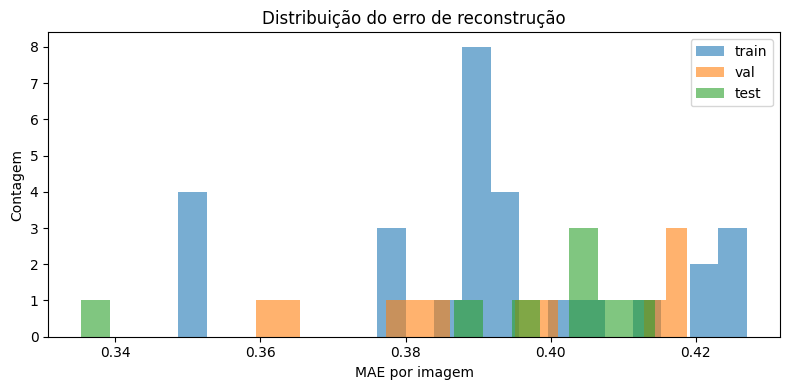

TypeError: Invalid shape (3, 224, 224) for image data

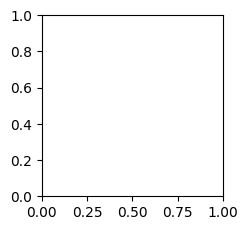

In [12]:
checkpoint = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print('Melhor val loss:', checkpoint['best_val_loss'])

def collect_recon_errors(loader):
    errors = []
    paths = []
    with torch.no_grad():
        for noisy, clean, _, batch_paths in loader:
            noisy = noisy.to(DEVICE, non_blocking=True)
            clean = clean.to(DEVICE, non_blocking=True)
            recon = model(noisy)
            batch_errors = torch.mean(torch.abs(recon - clean), dim=(1, 2, 3)).detach().cpu().numpy()
            errors.extend(batch_errors.tolist())
            paths.extend(list(batch_paths))
    return np.asarray(errors), paths

train_errors, _ = collect_recon_errors(train_loader)
val_errors, _ = collect_recon_errors(val_loader)
test_errors, test_paths = collect_recon_errors(test_loader)

error_summary = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'mean_abs_error': [train_errors.mean(), val_errors.mean(), test_errors.mean()],
    'median_abs_error': [np.median(train_errors), np.median(val_errors), np.median(test_errors)],
    'n': [len(train_errors), len(val_errors), len(test_errors)],
})
display(error_summary)

plt.figure(figsize=(8, 4))
plt.hist(train_errors, bins=20, alpha=0.6, label='train')
plt.hist(val_errors, bins=20, alpha=0.6, label='val')
plt.hist(test_errors, bins=20, alpha=0.6, label='test')
plt.title('Distribuição do erro de reconstrução')
plt.xlabel('MAE por imagem')
plt.ylabel('Contagem')
plt.legend()
plt.tight_layout()
plt.show()

def show_reconstructions(loader, n=6, title='Reconstruções V'):
    noisy, clean, _, _ = next(iter(loader))
    noisy = noisy.to(DEVICE)[:n]
    clean = clean[:n]
    with torch.no_grad():
        recon = model(noisy).cpu()
    n = min(n, clean.size(0))
    plt.figure(figsize=(3 * n, 8))
    for idx in range(n):
        plt.subplot(3, n, idx + 1)
        plt.imshow(clean[idx].squeeze(0), cmap='gray')
        plt.axis('off')
        if idx == 0:
            plt.ylabel('Clean')
        plt.subplot(3, n, n + idx + 1)
        plt.imshow(noisy[idx].detach().cpu().squeeze(0), cmap='gray')
        plt.axis('off')
        if idx == 0:
            plt.ylabel('Input')
        plt.subplot(3, n, 2 * n + idx + 1)
        plt.imshow(recon[idx].squeeze(0), cmap='gray')
        plt.axis('off')
        if idx == 0:
            plt.ylabel('Recon')
    plt.suptitle(title)
    plt.tight_layout()
    out_path = RESULTS_DIR / 'reconstructions.png'
    plt.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)

show_reconstructions(test_loader, n=6, title='Reconstruções no conjunto de teste V')

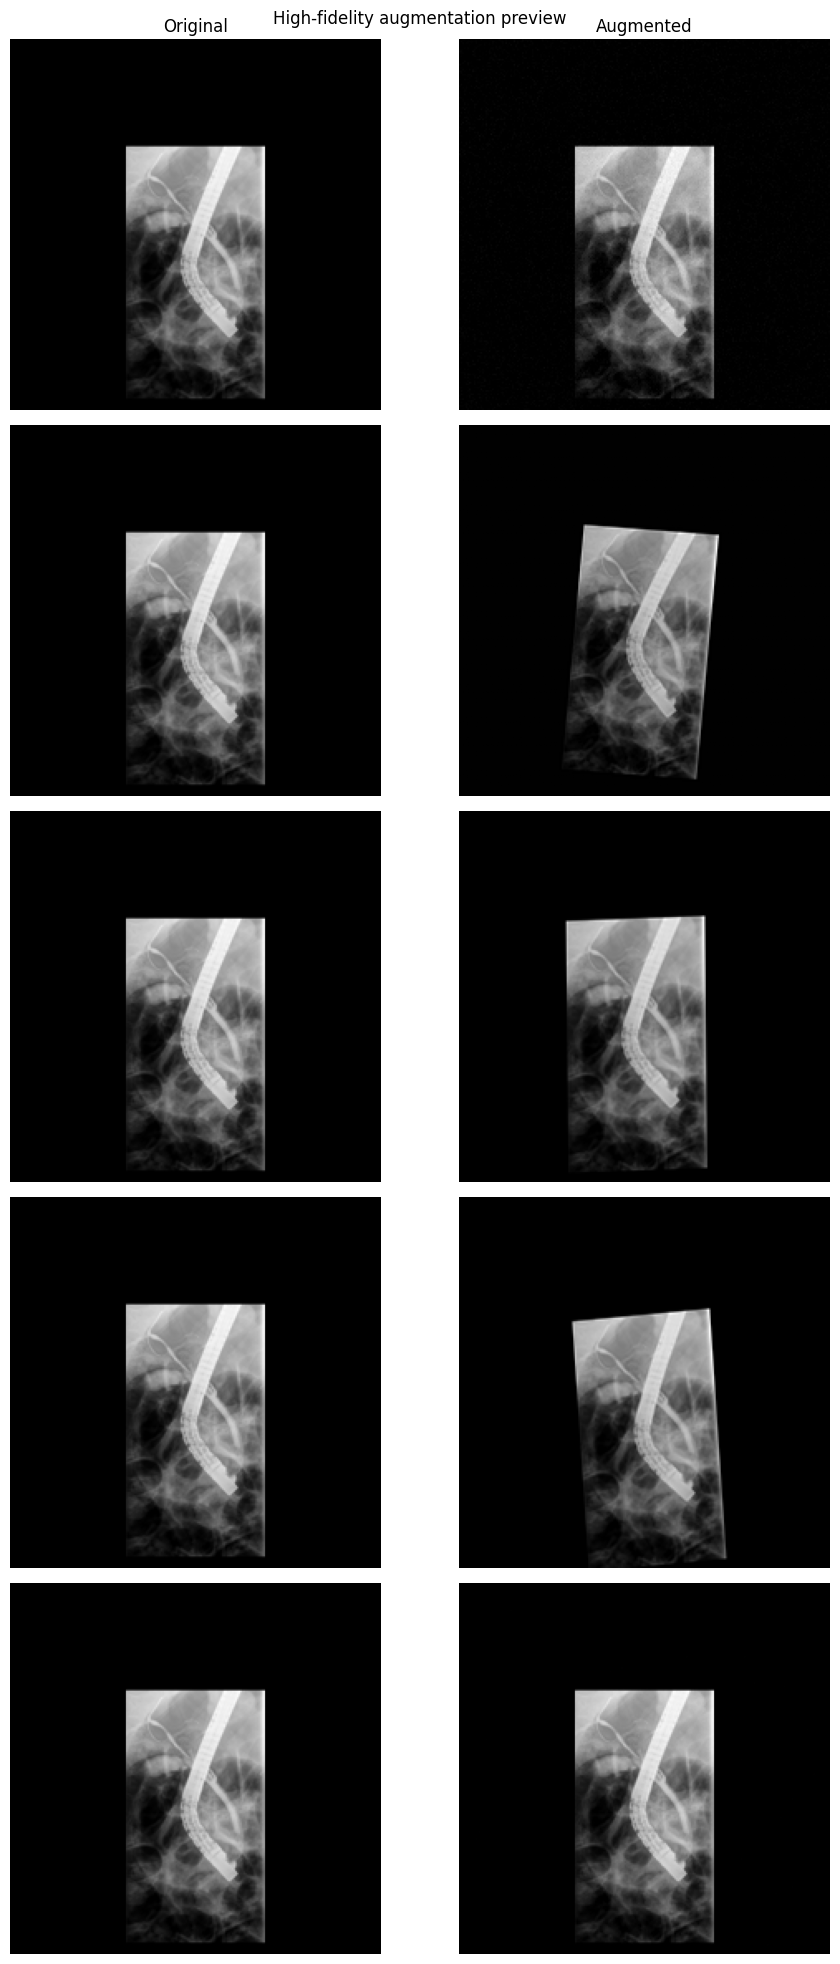

Saved preview: results\auto_encode_V\augmented_v_preview.png
Saved augmented images to: results\auto_encode_V\augmented_v_samples
Saved manifest to: results\auto_encode_V\augmented_v_manifest.csv
Saved augmented metadata to: results\auto_encode_V\augmented_v_metadata.csv
Total generated: 224


,raw_image_path,processed_image_path,generated_image_path,source_image_path,patient_id,image_type,Label,final_label,Keep,exam_date,exam_time,group_key,target,variant_idx,variants_per_image,method
0,raw/1488_image18832.png,processed/1488_image18832_section_1.png,results\auto_encode_V\augmented_v_samples\v_au...,MIQR-CC-Dataset\processed\1488_image18832_sect...,1488,V,Normal,Normal,keep,12/01/2017,11:28:31,1488_12/01/2017_11:28:31,2,1,8,high_fidelity_augmentation
1,raw/1488_image18832.png,processed/1488_image18832_section_1.png,results\auto_encode_V\augmented_v_samples\v_au...,MIQR-CC-Dataset\processed\1488_image18832_sect...,1488,V,Normal,Normal,keep,12/01/2017,11:28:31,1488_12/01/2017_11:28:31,2,2,8,high_fidelity_augmentation
2,raw/1488_image18832.png,processed/1488_image18832_section_1.png,results\auto_encode_V\augmented_v_samples\v_au...,MIQR-CC-Dataset\processed\1488_image18832_sect...,1488,V,Normal,Normal,keep,12/01/2017,11:28:31,1488_12/01/2017_11:28:31,2,3,8,high_fidelity_augmentation
3,raw/1488_image18832.png,processed/1488_image18832_section_1.png,results\auto_encode_V\augmented_v_samples\v_au...,MIQR-CC-Dataset\processed\1488_image18832_sect...,1488,V,Normal,Normal,keep,12/01/2017,11:28:31,1488_12/01/2017_11:28:31,2,4,8,high_fidelity_augmentation
4,raw/1488_image18832.png,processed/1488_image18832_section_1.png,results\auto_encode_V\augmented_v_samples\v_au...,MIQR-CC-Dataset\processed\1488_image18832_sect...,1488,V,Normal,Normal,keep,12/01/2017,11:28:31,1488_12/01/2017_11:28:31,2,5,8,high_fidelity_augmentation


In [13]:
def _pil_to_tensor(image):
    return transforms.ToTensor()(image)


def _tensor_to_pil(tensor):
    return transforms.ToPILImage()(tensor.clamp(0.0, 1.0))


def augment_v_image(image):
    """Generate a high-fidelity variant that stays close to the source image."""
    image = ImageOps.pad(image, IMAGE_SIZE, method=Image.Resampling.BICUBIC, color=0, centering=(0.5, 0.5))
    image = ImageOps.grayscale(image)

    if random.random() < 0.75:
        angle = random.uniform(-6.0, 6.0)
        translate = (
            int(random.uniform(-0.03, 0.03) * IMAGE_SIZE[0]),
            int(random.uniform(-0.03, 0.03) * IMAGE_SIZE[1]),
        )
        scale = random.uniform(0.95, 1.03)
        shear = random.uniform(-3.0, 3.0)
        image = transforms.functional.affine(
            image,
            angle=angle,
            translate=translate,
            scale=scale,
            shear=[shear, 0.0],
            interpolation=transforms.InterpolationMode.BICUBIC,
            fill=0,
        )

    if random.random() < 0.7:
        brightness = random.uniform(0.92, 1.08)
        contrast = random.uniform(0.90, 1.10)
        image = transforms.functional.adjust_brightness(image, brightness)
        image = transforms.functional.adjust_contrast(image, contrast)

    if random.random() < 0.3:
        sharpness_factor = random.uniform(0.85, 1.25)
        image = transforms.functional.adjust_sharpness(image, sharpness_factor)

    tensor = _pil_to_tensor(image)

    if random.random() < 0.25:
        sigma = random.uniform(0.0, 0.02)
        tensor = (tensor + sigma * torch.randn_like(tensor)).clamp(0.0, 1.0)

    if random.random() < 0.20:
        blur_kernel = random.choice([3, 5])
        blur_sigma = random.uniform(0.1, 0.8)
        tensor = transforms.functional.gaussian_blur(tensor, kernel_size=blur_kernel, sigma=blur_sigma)

    return tensor.clamp(0.0, 1.0)


def generate_augmented_v_dataset(source_frame, variants_per_image=8, save_previews=5):
    output_dir = RESULTS_DIR / 'augmented_v_samples'
    output_dir.mkdir(parents=True, exist_ok=True)

    manifest_records = []
    metadata_records = []
    preview_pairs = []
    generated_count = 0

    for row_index, row in source_frame.reset_index(drop=True).iterrows():
        source_path = Path(row['image_path'])
        source_image = Image.open(source_path).convert('RGB')

        for variant_index in range(variants_per_image):
            augmented_tensor = augment_v_image(source_image)
            generated_count += 1
            output_path = output_dir / f"v_aug_{row_index:05d}_{variant_index + 1:02d}.png"
            _tensor_to_pil(augmented_tensor).save(output_path)

            manifest_records.append({
                'source_image': str(source_path),
                'generated_image': str(output_path),
                'patient_id': row['patient_id'],
                'group_key': row['group_key'],
                'image_type': 'V',
                'Keep': 'Keep',
                'variant_idx': variant_index + 1,
                'variants_per_image': variants_per_image,
                'method': 'high_fidelity_augmentation',
            })

            metadata_records.append({
                'raw_image_path': row.get('raw_image_path', ''),
                'processed_image_path': row.get('processed_image_path', str(source_path)),
                'generated_image_path': str(output_path),
                'source_image_path': str(source_path),
                'patient_id': row['patient_id'],
                'image_type': row.get('image_type', 'V'),
                'Label': row['Label'],
                'final_label': row['final_label'],
                'Keep': row['Keep'],
                'exam_date': row['exam_date'],
                'exam_time': row['exam_time'],
                'group_key': row['group_key'],
                'target': int(row['target']),
                'variant_idx': variant_index + 1,
                'variants_per_image': variants_per_image,
                'method': 'high_fidelity_augmentation',
            })

            if row_index < save_previews:
                preview_pairs.append((source_image, augmented_tensor, row_index, variant_index + 1))

    manifest = pd.DataFrame(manifest_records)
    manifest_path = RESULTS_DIR / 'augmented_v_manifest.csv'
    manifest.to_csv(manifest_path, index=False)

    augmented_metadata = pd.DataFrame(metadata_records)
    metadata_path = RESULTS_DIR / 'augmented_v_metadata.csv'
    augmented_metadata.to_csv(metadata_path, index=False)

    preview_count = min(len(preview_pairs), save_previews)
    if preview_count > 0:
        plt.figure(figsize=(10, 4 * preview_count))
        for idx, (source_image, augmented_tensor, row_index, variant_index) in enumerate(preview_pairs[:preview_count], start=1):
            plt.subplot(preview_count, 2, 2 * idx - 1)
            plt.imshow(ImageOps.grayscale(ImageOps.pad(source_image, IMAGE_SIZE, method=Image.Resampling.BICUBIC, color=0, centering=(0.5, 0.5))), cmap='gray')
            plt.axis('off')
            if idx == 1:
                plt.title('Original')
            plt.ylabel(f'Sample {row_index + 1}')

            plt.subplot(preview_count, 2, 2 * idx)
            plt.imshow(augmented_tensor.squeeze(0), cmap='gray')
            plt.axis('off')
            if idx == 1:
                plt.title('Augmented')
        plt.suptitle('High-fidelity augmentation preview')
        plt.tight_layout()
        preview_path = RESULTS_DIR / 'augmented_v_preview.png'
        plt.savefig(preview_path, dpi=160, bbox_inches='tight')
        plt.show()
        print('Saved preview:', preview_path)

    print('Saved augmented images to:', output_dir)
    print('Saved manifest to:', manifest_path)
    print('Saved augmented metadata to:', metadata_path)
    print('Total generated:', generated_count)
    return manifest, augmented_metadata


augmented_meta, augmented_metadata = generate_augmented_v_dataset(train_v_source, variants_per_image=8, save_previews=5)
display(augmented_metadata.head())

## What to look at next

- `results/auto_encode_V/training_history.csv` for loss curves if you keep the autoencoder training section.
- `results/auto_encode_V/reconstructions.png` for reconstruction quality.
- `results/auto_encode_V/augmented_v_manifest.csv` and `results/auto_encode_V/augmented_v_samples/` for the high-fidelity augmented dataset.

If your goal is more quantity, keep `variants_per_image` high and keep the augmentation strength low. That gives you many more samples without destroying the anatomy.

In [22]:
from torchsummary import summary

model = ConvAutoencoder().to(DEVICE)

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
         LeakyReLU-3         [-1, 32, 112, 112]               0
         ConvBlock-4         [-1, 32, 112, 112]               0
            Conv2d-5           [-1, 64, 56, 56]          18,432
       BatchNorm2d-6           [-1, 64, 56, 56]             128
         LeakyReLU-7           [-1, 64, 56, 56]               0
         ConvBlock-8           [-1, 64, 56, 56]               0
            Conv2d-9          [-1, 128, 28, 28]          73,728
      BatchNorm2d-10          [-1, 128, 28, 28]             256
        LeakyReLU-11          [-1, 128, 28, 28]               0
        ConvBlock-12          [-1, 128, 28, 28]               0
           Conv2d-13          [-1, 256, 14, 14]         294,912
      BatchNorm2d-14          [-1, 256,

In [20]:
import torch
from torchviz import make_dot

model = ConvAutoencoder()

# Dummy input
x = torch.zeros(1, 3, 224, 224)

# Forward pass to get the output
y = model(x)

# Create visualization
dot = make_dot(y, params=dict(model.named_parameters()))

# Save the graph
dot.render("model_architecture", format="png", cleanup=True)

'model_architecture.png'